In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/featured_leads.csv")
print("Shape:", df.shape)
df.head()

Shape: (9240, 93)


,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Search,Newspaper Article,X Education Forums,Newspaper,...,City_Other Metro Cities,City_Thane & Outskirts,City_Tier II Cities,City_Unknown,Last Notable Activity_Email Opened,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Other,Last Notable Activity_Page Visited on Website,Last Notable Activity_SMS Sent
0,0,0,0,0.0,0,0.0,0,0,0,0,...,False,False,False,True,False,True,False,False,False,False
1,0,0,0,5.0,674,2.5,0,0,0,0,...,False,False,False,True,True,False,False,False,False,False
2,0,0,1,2.0,1532,2.0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,0,0,0,1.0,305,1.0,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False
4,0,0,1,2.0,1428,1.0,0,0,0,0,...,False,False,False,False,False,True,False,False,False,False


In [2]:
X = df.drop(columns=['Converted'])
y = df['Converted']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9240, 92)
Target shape: (9240,)


In [3]:
correlations = df.corr()['Converted'].sort_values(ascending=False)
print("Top 15 positively correlated features:")
print(correlations.head(15))

print("\nTop 15 negatively correlated features:")
print(correlations.tail(15))

Top 15 positively correlated features:
Converted                                               1.000000
Tags_Will revert after reading the email                0.644307
Total Time Spent on Website                             0.362483
Last Notable Activity_SMS Sent                          0.351845
Lead Quality_Might be                                   0.342988
Last Activity_SMS Sent                                  0.325600
Lead Origin_Lead Add Form                               0.321702
What is your current occupation_Working Professional    0.313837
Lead Source_Reference                                   0.270830
Tags_Closed by Horizzon                                 0.251229
Lead Quality_Low in Relevance                           0.230770
Tags_Lost to EINS                                       0.168937
Lead Source_Welingak Website                            0.154153
What is your current occupation_Unemployed              0.128710
Specialization_Marketing Management                

In [4]:
leakage_cols = [col for col in df.columns if col.startswith(('Tags_', 'Lead Quality_', 'Last Activity_', 'Last Notable Activity_'))]
print("Dropping these leakage-prone columns:")
print(leakage_cols)

df_clean = df.drop(columns=leakage_cols)
print("\nShape after dropping leakage columns:", df_clean.shape)

Dropping these leakage-prone columns:
['Last Activity_Email Bounced', 'Last Activity_Email Link Clicked', 'Last Activity_Email Opened', 'Last Activity_Form Submitted on Website', 'Last Activity_Olark Chat Conversation', 'Last Activity_Other', 'Last Activity_Page Visited on Website', 'Last Activity_SMS Sent', 'Last Activity_Unreachable', 'Tags_Busy', 'Tags_Closed by Horizzon', 'Tags_Graduation in progress', 'Tags_Interested  in full time MBA', 'Tags_Interested in other courses', 'Tags_Lost to EINS', 'Tags_Not doing further education', 'Tags_Other', 'Tags_Ringing', 'Tags_Unknown', 'Tags_Will revert after reading the email', 'Tags_switched off', 'Lead Quality_Low in Relevance', 'Lead Quality_Might be', 'Lead Quality_Not Sure', 'Lead Quality_Unknown', 'Lead Quality_Worst', 'Last Notable Activity_Email Opened', 'Last Notable Activity_Modified', 'Last Notable Activity_Olark Chat Conversation', 'Last Notable Activity_Other', 'Last Notable Activity_Page Visited on Website', 'Last Notable Activ

In [5]:
X = df_clean.drop(columns=['Converted'])
y = df_clean['Converted']

correlations = df_clean.corr()['Converted'].sort_values(ascending=False)
print("Top 15 positively correlated (post-cleanup):")
print(correlations.head(15))

Top 15 positively correlated (post-cleanup):
Converted                                               1.000000
Total Time Spent on Website                             0.362483
Lead Origin_Lead Add Form                               0.321702
What is your current occupation_Working Professional    0.313837
Lead Source_Reference                                   0.270830
Lead Source_Welingak Website                            0.154153
What is your current occupation_Unemployed              0.128710
Specialization_Marketing Management                     0.065853
Country_Unknown                                         0.064167
Specialization_Human Resource Management                0.047130
Specialization_Finance Management                       0.043308
Specialization_Operations Management                    0.043272
What is your current occupation_Housewife               0.041567
City_Thane & Outskirts                                  0.039189
Specialization_Healthcare Management         

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 20 Most Important Features (Random Forest):")
print(importances.head(20))

Top 20 Most Important Features (Random Forest):
Total Time Spent on Website                              0.387645
Page Views Per Visit                                     0.071154
TotalVisits                                              0.070265
What is your current occupation_Working Professional     0.050357
Lead Origin_Lead Add Form                                0.044023
What matters most to you in choosing a course_Unknown    0.037153
What is your current occupation_Unknown                  0.035221
Lead Source_Reference                                    0.019494
What is your current occupation_Unemployed               0.017845
Specialization_Unknown                                   0.016370
Do Not Email                                             0.014780
Lead Origin_Landing Page Submission                      0.014706
Lead Source_Google                                       0.013042
A free copy of Mastering The Interview                   0.012909
City_Thane & Outskirts      

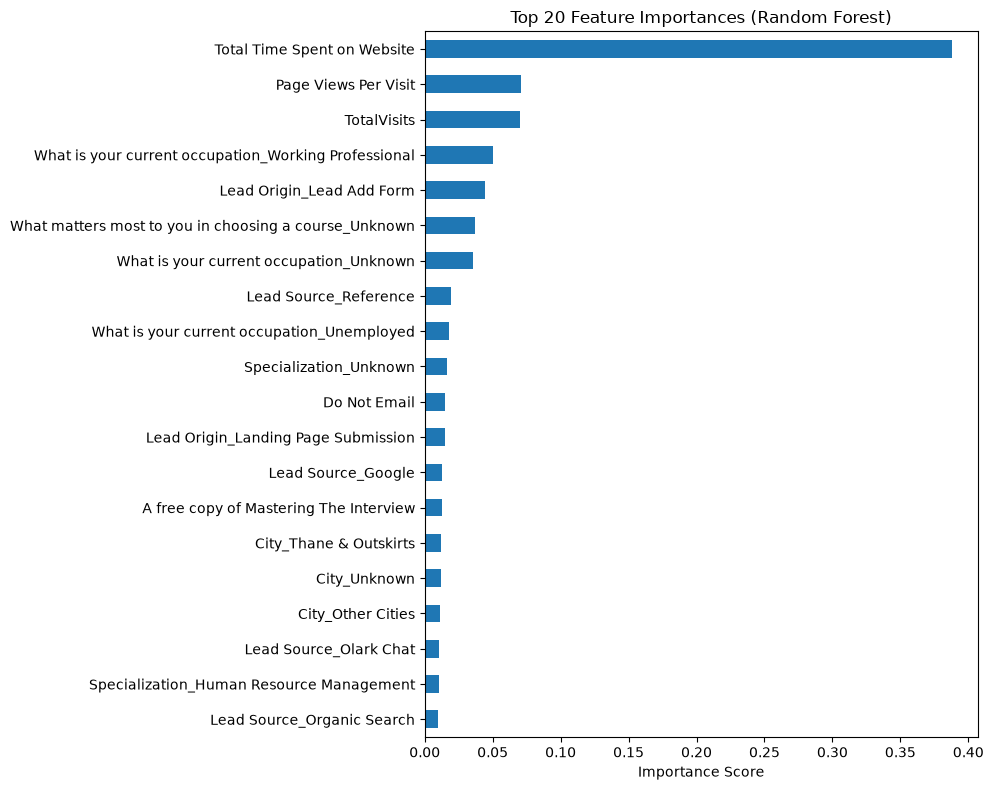

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
top_features = importances.head(30).index.tolist()
final_cols = top_features + ['Converted']

df_final = df_clean[final_cols]
df_final.to_csv("../data/processed/final_features.csv", index=False)

print("✅ Final feature-selected dataset saved!")
print("Final shape:", df_final.shape)

✅ Final feature-selected dataset saved!
Final shape: (9240, 31)
